In [1]:
from SDP_interaction_inference.constraints import Constraint
from SDP_interaction_inference import optimization
from SDP_interaction_inference.dataset import Dataset
from SDP_interaction_inference.correlation import Correlation
from SDP_interaction_inference import utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import scipy
import tqdm
from copy import deepcopy
import matplotlib.patches
import corner
import plotly
import plotly.graph_objects as go

# Model Free Investigation

## Data Loading

In [2]:
# read fibroblast transcript counts
data_FIB = pd.read_csv("./Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("./Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("./Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# separate data
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

# amounts: see './Biotypes/updated-biotypes.ipynb' for full pie chart of types
print(f"Total of {data_FIB.shape[0]} genes with mean > 1 present \nSelected {data_FIB_miRNA.shape[0]} non-coding miRNA \nSelected {data_FIB_pcRNA.shape[0]} protein coding (mRNA)")

Total of 11747 genes with mean > 1 present 
Selected 19 non-coding miRNA 
Selected 9296 protein coding (mRNA)


## Select miRNA

In [ ]:
# load result dataframes
correlation_df = pd.read_csv("./Results/correlations.csv", index_col=0)
analytic_df = pd.read_csv("./Results/analytic.csv", index_col=0)
independent_MF_df = pd.read_csv("./Results/independent_MF.csv", index_col=0)
interacting_MF_df = pd.read_csv("./Results/interacting_MF.csv", index_col=0)

In [8]:
# select mRNA and miNRA names
mRNA_names = [name for name, btype in biotypes_dict.items() if btype == "protein_coding"]
miRNA_names = [name for name, btype in biotypes_dict.items() if btype == "miRNA"]

In [4]:
# set colours for all plots
plot_colours = {
    "OPTIMAL": "green",
    "INFEASIBLE": "red",
    "CUT_LIMIT": "blue",
    "TIME_LIMIT": "orange",
    "TOTAL_TIME_LIMIT": "pink",
    "NUMERIC": "black"
}

In [5]:
# set display names for status codes
display_names = {
    "OPTIMAL": "FEASIBLE",
    "INFEASIBLE": "INFEASIBLE",
    "CUT_LIMIT": "CUT_LIMIT",
    "TIME_LIMIT": "TIME_LIMIT",
    "TOTAL_TIME_LIMIT": "TOTAL_TIME_LIMIT",
    "NUMERIC": "NUMERIC"
}

In [21]:
def observed_correlation_by_status_histogram(dataframe, d, c, title, G1, G2):

    # subplots
    m, n = 4, 5
    fig, axs = plt.subplots(m, n, figsize=(16, 16))

    mask_G = (np.arange(dataframe.shape[0]) >= G1) & (np.arange(dataframe.shape[0]) < G2)

    # for each miRNA
    for k, miRNA in enumerate(miRNA_names):
        
        # select subplot
        i = k // n
        j = k % n

        # get data
        correlation = correlation_df[f'{miRNA}_rho'][mask_G]
        status = dataframe[f'{miRNA}_d{d}_c{c}_status'][mask_G]
        status_names = np.unique(status)

        # plot
        status_order = ["OPTIMAL", "CUT_LIMIT", "TIME_LIMIT", "TOTAL_TIME_LIMIT", "NUMERIC", "INFEASIBLE"]
        for name in status_order:
            correlation_status = correlation.loc[status == name]
            L = len(correlation_status)
            if L == 0: continue
            bins = int(np.sqrt(L))
            axs[i, j].hist(
                correlation_status,
                bins=bins,
                alpha=0.75,
                label=f"{display_names[name]} ({round(100 * len(correlation_status) / (G2 - G1), 1)}%)",
                color=plot_colours[name]
            )
        axs[i, j].set_title(miRNA)
        axs[i, j].set_xlabel("Observed correlation")
        axs[i, j].set_ylabel("Frequency")
        axs[i, j].legend()

    # text legend
    axs[m - 1, n - 1].axis('off')
    k = 0
    for name, colour in plot_colours.items():
        axs[m - 1, n - 1].text(0.2, 0.8, f"d = {d}, c = {c}%", fontsize=15)
        axs[m - 1, n - 1].text(0.3, 0.7 - k*0.1, display_names[name], fontsize=15, color=colour)
        k+=1

    # title
    plt.suptitle(f"{title}: Observed correlation distribution per status (per miRNA)")
    plt.tight_layout()
    plt.show()

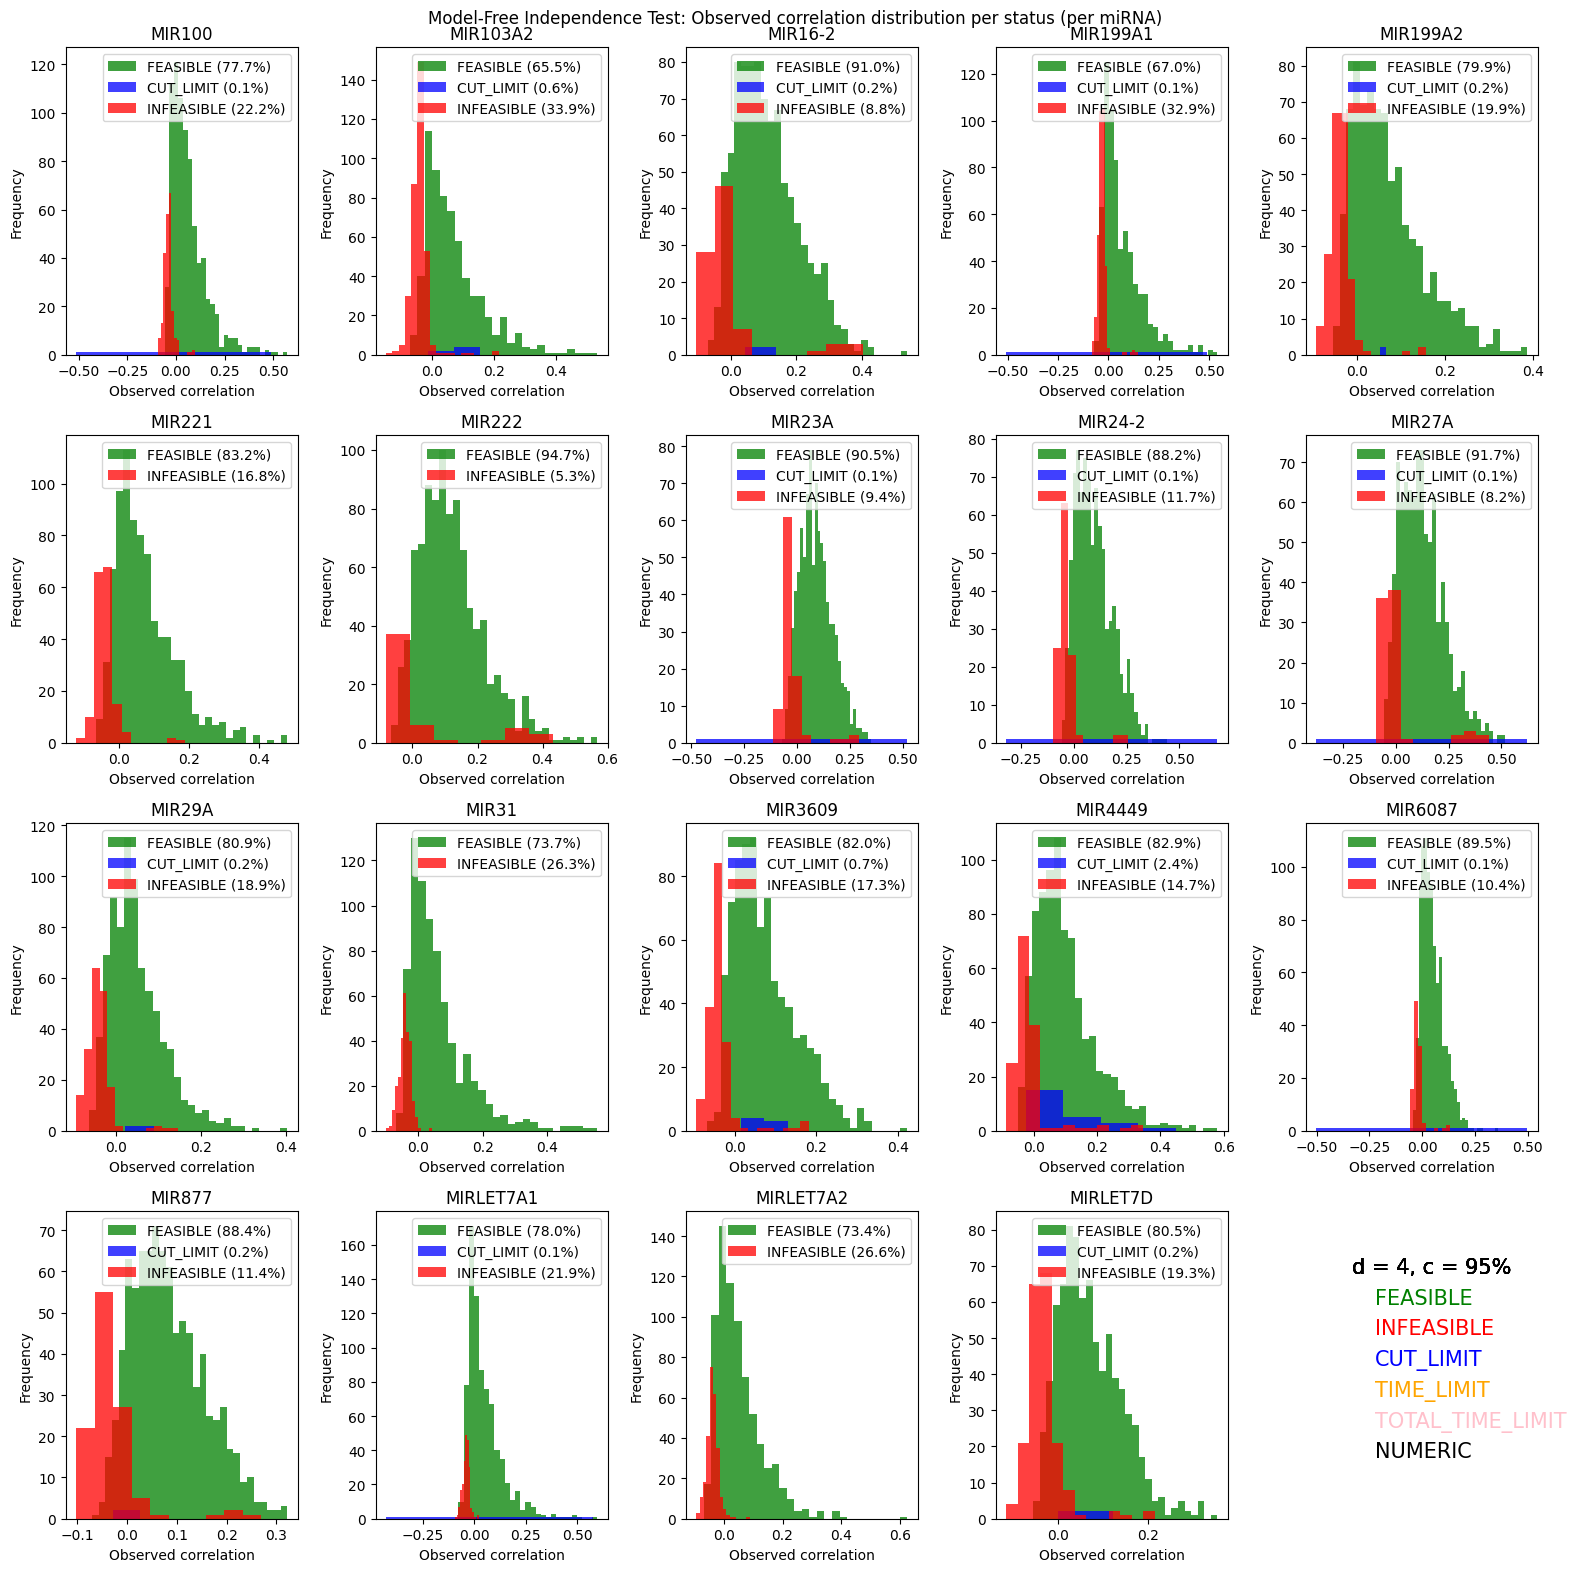

In [23]:
observed_correlation_by_status_histogram(independent_MF_df, 4, 95, "Model-Free Independence Test", 0, 1000)

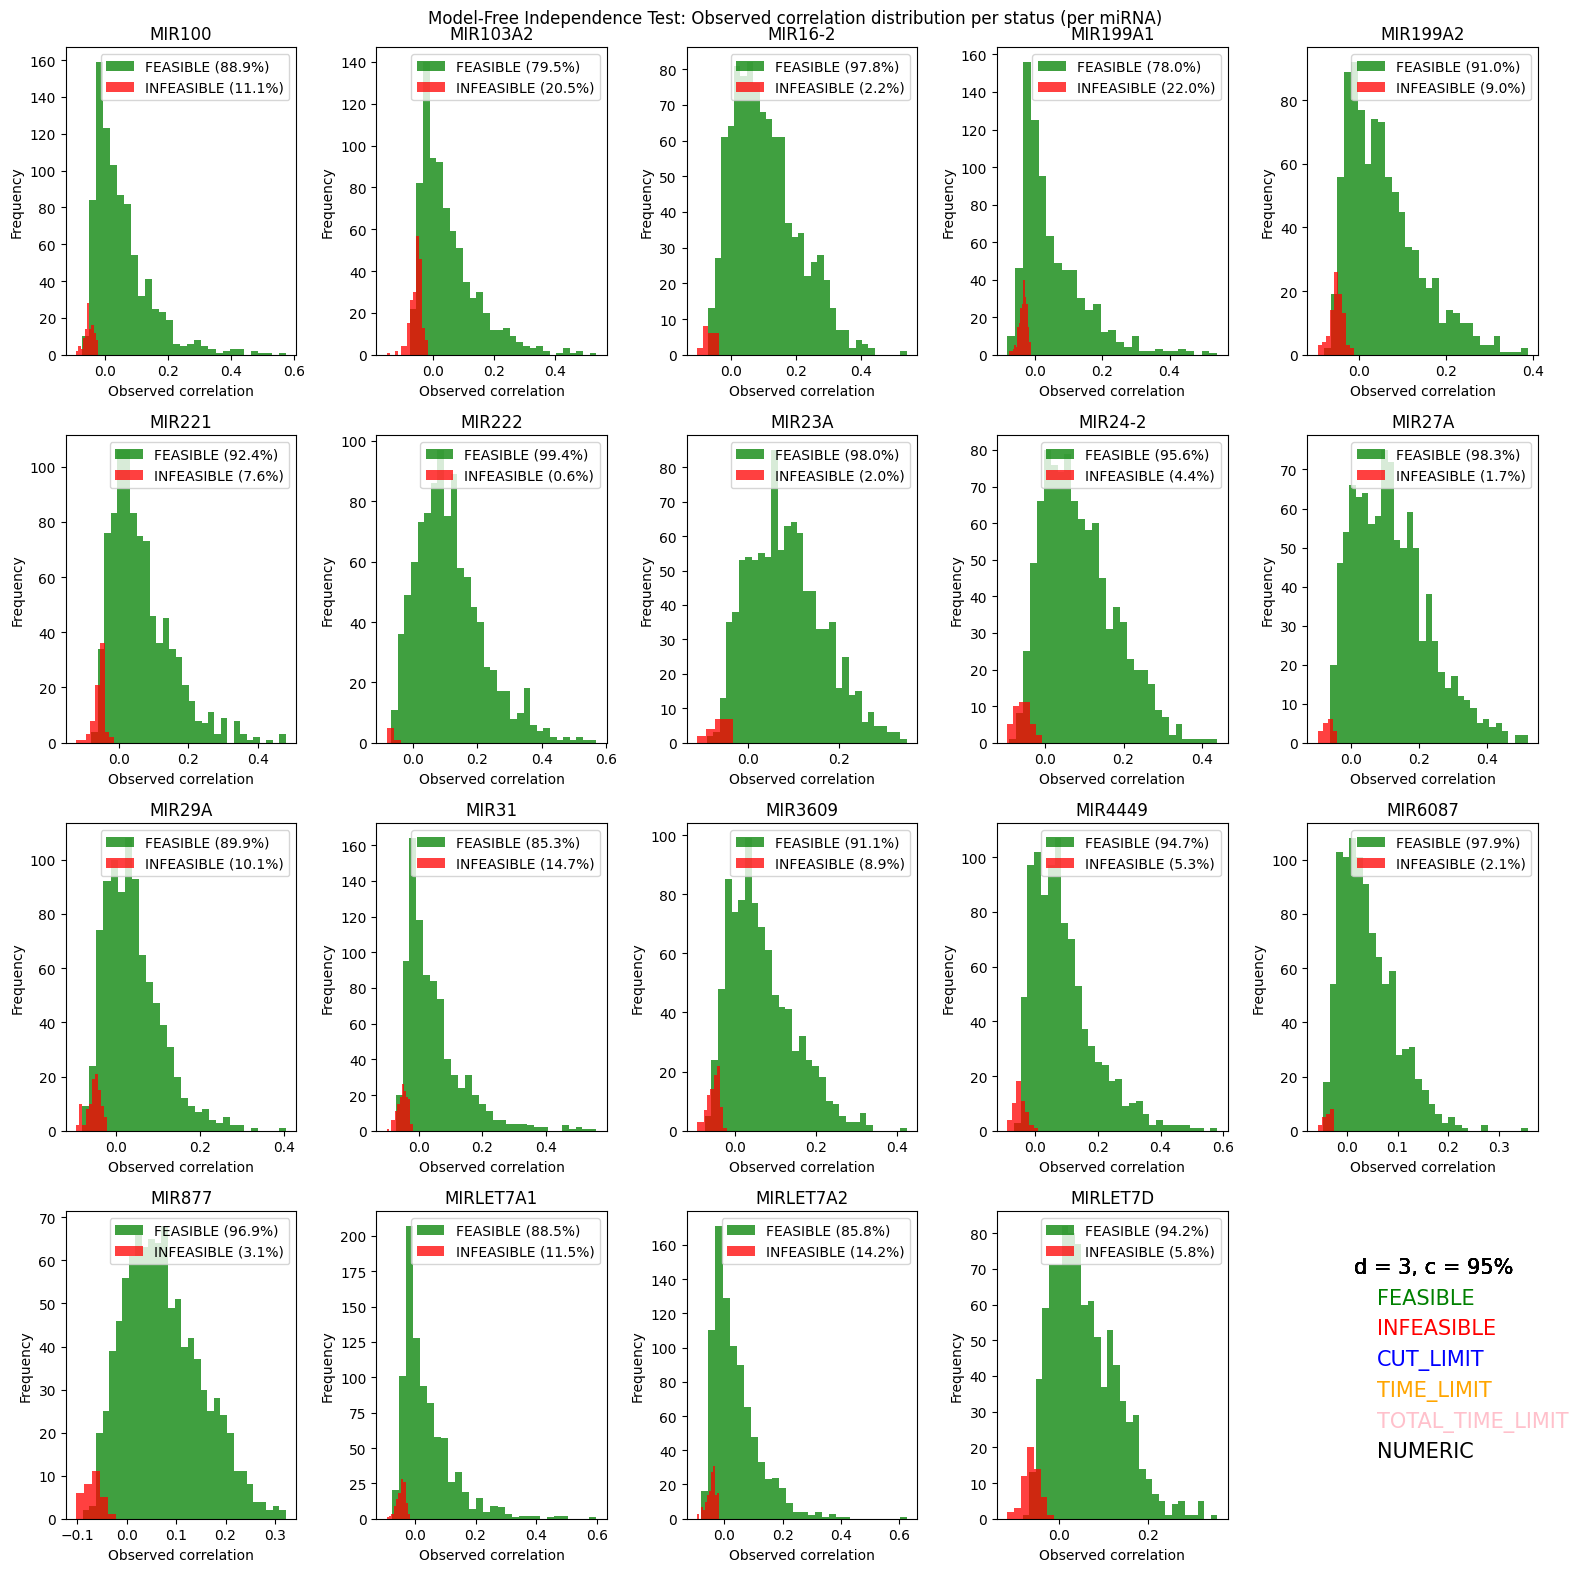

In [ ]:
observed_correlation_by_status_histogram(independent_MF_df, 3, 95, "Model-Free Independence Test", 0, 1000)

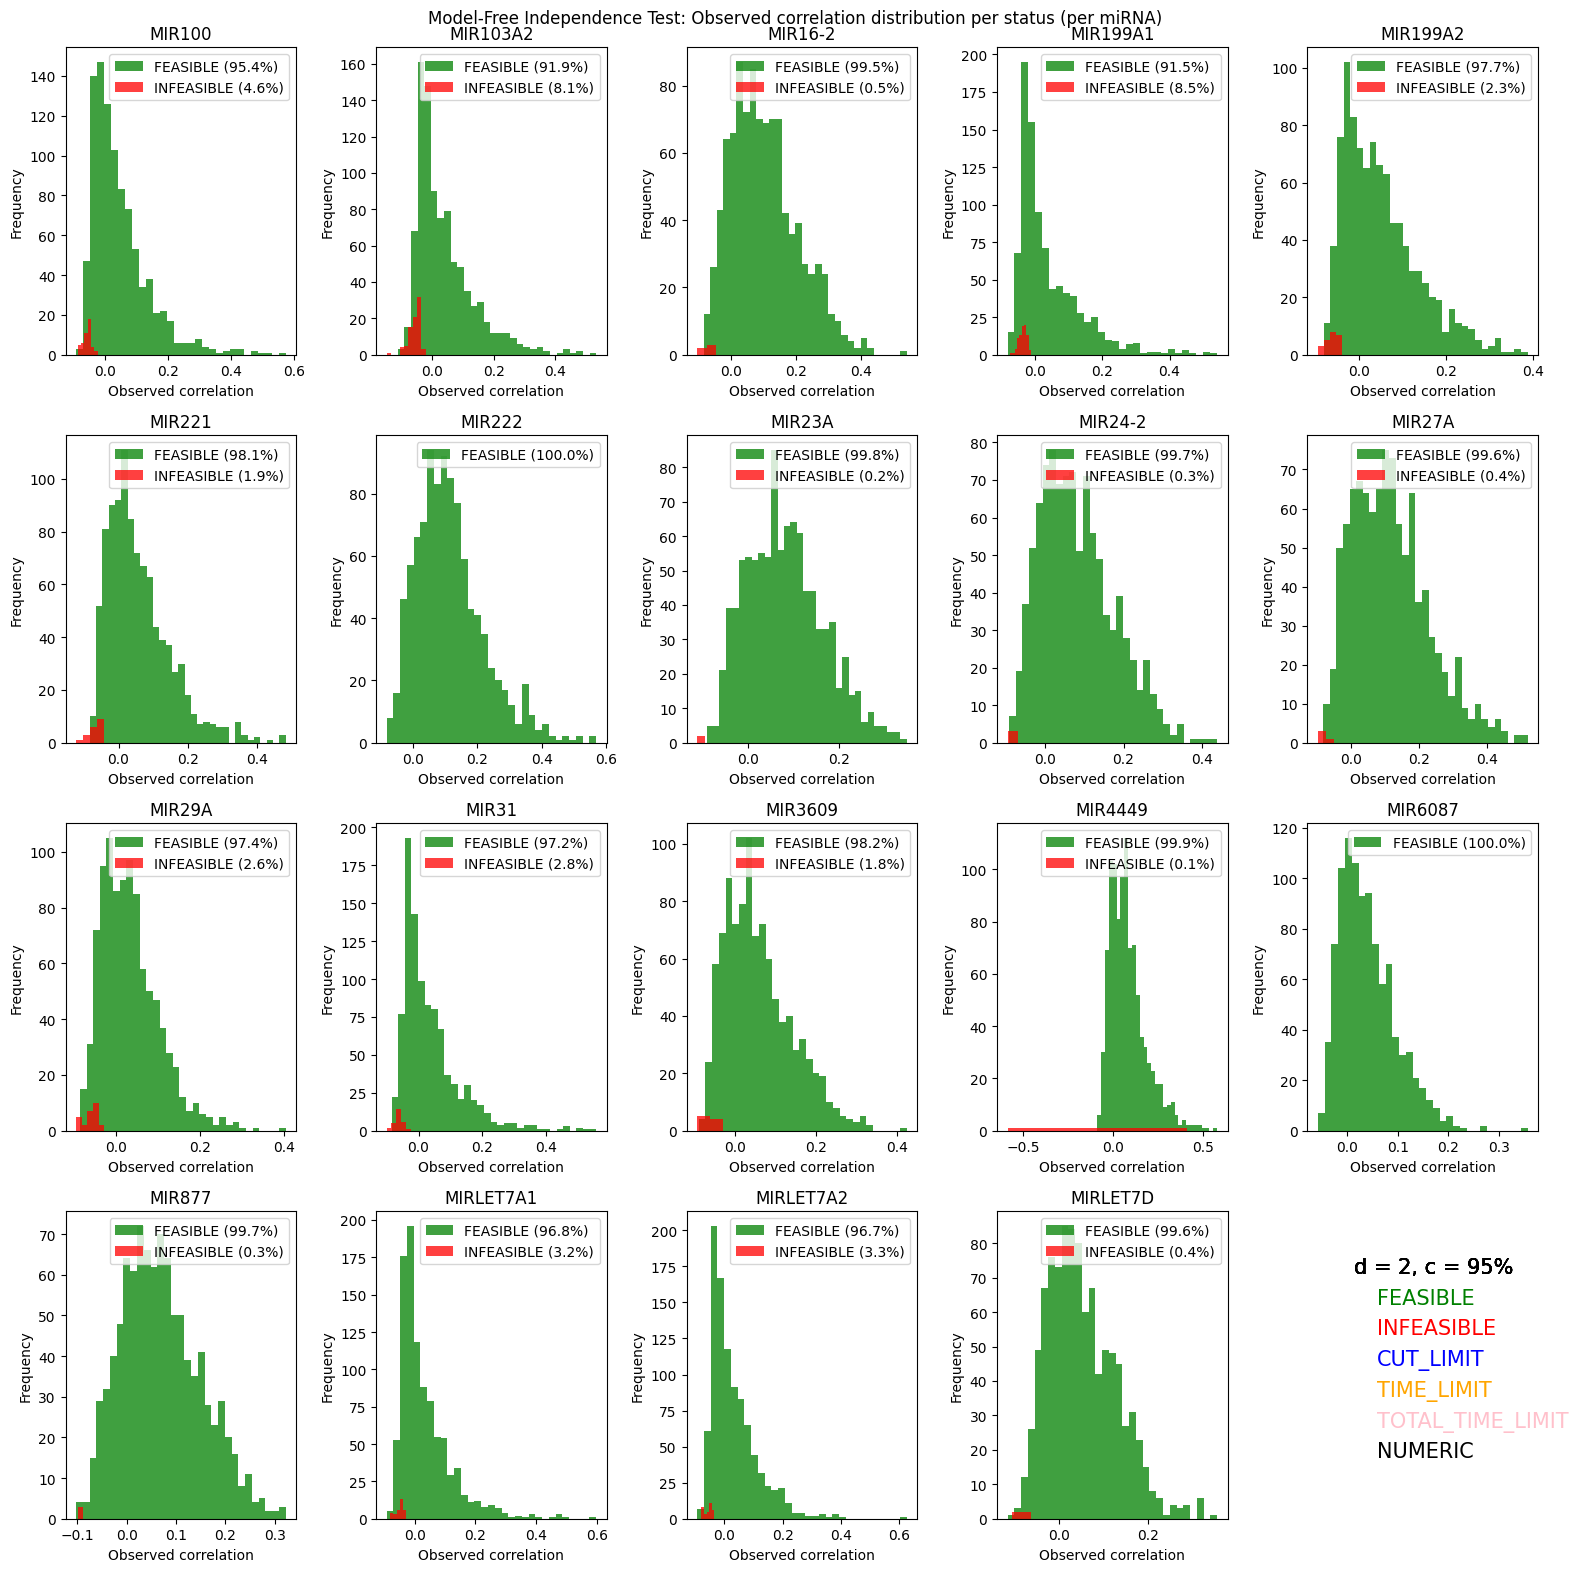

In [ ]:
observed_correlation_by_status_histogram(independent_MF_df, 2, 95, "Model-Free Independence Test", 0, 1000)

## Setup functions

In [24]:
def construct_dataset(mirna_sample, mrna_dataset, beta, resamples=1000):

    # size
    gene_pairs, cells = mrna_dataset.shape

    # construct paired count dataframe
    counts_df = pd.DataFrame(
        index = [f"Gene-pair-{i}" for i in range(gene_pairs)],
        columns = [f"Cell-{j}" for j in range(cells)]
    )

    # fill with pairs
    for i in range(gene_pairs):
        gene_i = mirna_sample
        gene_j = mrna_dataset.iloc[i]
        gene_pair_ij = list(zip(gene_i, gene_j))
        counts_df.iloc[i] = gene_pair_ij

    # construct dataset object
    data = Dataset()
    data.count_dataset = counts_df
    data.cells = cells
    data.gene_pairs = gene_pairs

    # settings
    data.resamples = resamples

    # set capture
    data.beta = beta

    return data

In [25]:
def model_free_independence_test(dataset, d_bd, d_sd, **kwargs):

    # Independent model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=True
    )
    opt_MF_ind = optimization.ModelFreeOptimization(dataset, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_ind.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_ind.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_ind.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_ind.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'model': opt_MF_ind
    }

    return data

In [26]:
def model_free_interacting_test(dataset, d_bd, d_sd, **kwargs):

    # Interacting model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=False
    )
    opt_MF_int = optimization.ModelFreeOptimization(dataset, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_int.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_int.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_int.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_int.result_dict.values()]
    correlation = [solution['correlation'] for solution in opt_MF_int.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'correlation': correlation,
        'model': opt_MF_int
    }

    return data

In [ ]:
def MF_analysis(d_bd, d_sd, time_limit, cut_limit):

    # settings
    time_limit = time_limit
    total_time_limit = time_limit
    cut_limit = cut_limit

    # independence test
    print("MF Independence test:")
    MF_ind = model_free_independence_test(dataset_SDP, d_bd, d_sd, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)

    # display results
    print(np.unique(MF_ind['status'], return_counts=True))

    # interacting test
    print("MF Interacting test:")
    MF_int = model_free_interacting_test(dataset_SDP, d_bd, d_sd, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)

    # display results
    print(np.unique(MF_int['status'], return_counts=True))

    # store results on dataframe

    # independence test
    MF_independent_order_df[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_status'] = MF_ind['status']
    MF_independent_order_df[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_times'] = MF_ind['times']
    MF_independent_order_df[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_cuts'] = MF_ind['cuts']

    # interacting test
    MF_interacting_order_df[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_status'] = MF_int['status']
    MF_interacting_order_df[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_times'] = MF_int['times']
    MF_interacting_order_df[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_cuts'] = MF_int['cuts']
    MF_interacting_order_df[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_correlation'] = MF_int['correlation']

    # save dataframes as safety
    MF_independent_order_df.to_csv("Results/Order/independent_MF_order.csv")  # Uncomment when running
    MF_interacting_order_df.to_csv("Results/Order/interacting_MF_order.csv")

## Setup results

### Construct

In [33]:
# select mRNA
mRNA = data_FIB_pcRNA.iloc[:1000].index

In [ ]:
# dataframe to store model free results
#MF_independent_order_df = pd.DataFrame(
#    index=mRNA
#)
#MF_interacting_order_df = pd.DataFrame(
#    index=mRNA
#)

### Load

In [ ]:
#MF_independent_df = pd.read_csv("Results/independent_order_MF.csv", index_col=0)
#MF_interacting_df = pd.read_csv("Results/interacting_order_MF.csv", index_col=0)

### Save

In [ ]:
#MF_independent_df.to_csv("Results/independent_order_MF.csv")
#MF_interacting_df.to_csv("Results/interacting_order_MF.csv")

# Running

## MIR222

In [30]:
# choose miRNA
miRNA = "MIR222"

# display miRNA
print(f"\nRunning {miRNA}")

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(data_FIB_miRNA.loc[miRNA], data_FIB_pcRNA.loc[mRNA], beta)

# bootstrap
print("Bootstrap:")
dataset_SDP.confidence = 0.95
dataset_SDP.bootstrap(d=4, tqdm_disable=False)


Running MIR222
Bootstrap:


100%|██████████| 1000/1000 [00:38<00:00, 26.05it/s]


### d_bd = d_sd

#### 100 cuts

In [39]:
MF_analysis(d_bd=4, d_sd=4, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [01:07<00:00, 14.82it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([ 63, 937]))
MF Interacting test:


100%|██████████| 1000/1000 [01:17<00:00, 12.89it/s]

(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([292,   6, 702]))


In [ ]:
MF_analysis(d_bd=3, d_sd=3, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [00:37<00:00, 26.48it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([  7, 993]))
MF Interacting test:


100%|██████████| 1000/1000 [00:34<00:00, 28.82it/s]

(array(['OPTIMAL'], dtype='<U7'), array([1000]))


In [ ]:
MF_analysis(d_bd=2, d_sd=2, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [00:19<00:00, 52.15it/s]


(array(['OPTIMAL'], dtype='<U7'), array([1000]))
MF Interacting test:


100%|██████████| 1000/1000 [00:16<00:00, 59.65it/s]


(array(['OPTIMAL'], dtype='<U7'), array([1000]))


#### 1000 cuts

In [112]:
MF_analysis(d_bd=4, d_sd=4, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [01:01<00:00, 16.25it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([ 63, 937]))
MF Interacting test:


100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([262,   6, 732]))


In [111]:
MF_analysis(d_bd=3, d_sd=3, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [00:34<00:00, 29.10it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([  7, 993]))
MF Interacting test:


100%|██████████| 1000/1000 [00:30<00:00, 32.55it/s]

(array(['OPTIMAL'], dtype='<U7'), array([1000]))


In [110]:
MF_analysis(d_bd=2, d_sd=2, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [00:19<00:00, 52.29it/s]


(array(['OPTIMAL'], dtype='<U7'), array([1000]))
MF Interacting test:


100%|██████████| 1000/1000 [00:17<00:00, 57.22it/s]

(array(['OPTIMAL'], dtype='<U7'), array([1000]))


### d_bd < d_sd

#### 100 cuts

In [40]:
MF_analysis(d_bd=2, d_sd=3, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [00:54<00:00, 18.23it/s]


(array(['CUT_LIMIT', 'OPTIMAL'], dtype='<U9'), array([ 45, 955]))
MF Interacting test:


100%|██████████| 1000/1000 [00:53<00:00, 18.86it/s]

(array(['CUT_LIMIT', 'OPTIMAL'], dtype='<U9'), array([  9, 991]))


In [41]:
MF_analysis(d_bd=2, d_sd=4, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [02:05<00:00,  7.94it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([467,  11, 522]))
MF Interacting test:


100%|██████████| 1000/1000 [03:10<00:00,  5.26it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'NUMERIC', 'OPTIMAL'], dtype='<U10'), array([945,   4,   1,  50]))


#### 1000 cuts

In [113]:
MF_analysis(d_bd=2, d_sd=3, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [01:12<00:00, 13.79it/s]


(array(['CUT_LIMIT', 'OPTIMAL'], dtype='<U9'), array([ 45, 955]))
MF Interacting test:


100%|██████████| 1000/1000 [01:01<00:00, 16.15it/s]


(array(['CUT_LIMIT', 'OPTIMAL'], dtype='<U9'), array([  8, 992]))


In [114]:
MF_analysis(d_bd=2, d_sd=4, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [08:26<00:00,  1.97it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([394,  12, 594]))
MF Interacting test:


100%|██████████| 1000/1000 [26:04<00:00,  1.56s/it]


(array(['CUT_LIMIT', 'INFEASIBLE', 'NUMERIC', 'OPTIMAL'], dtype='<U10'), array([267,   6,   1, 726]))


## MIR199A1

In [143]:
# choose miRNA
miRNA = "MIR199A1"

# display miRNA
print(f"\nRunning {miRNA}")

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(data_FIB_miRNA.loc[miRNA], data_FIB_pcRNA.loc[mRNA], beta)

# bootstrap
print("Bootstrap:")
dataset_SDP.confidence = 0.95
dataset_SDP.bootstrap(d=4, tqdm_disable=False)


Running MIR199A1
Bootstrap:


100%|██████████| 1000/1000 [00:43<00:00, 23.09it/s]


### d_bd = d_sd

#### 100 cuts

In [148]:
MF_analysis(d_bd=4, d_sd=4, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [00:57<00:00, 17.38it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([327, 673]))
MF Interacting test:


100%|██████████| 1000/1000 [01:12<00:00, 13.73it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([170,   5, 825]))


In [147]:
MF_analysis(d_bd=3, d_sd=3, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [00:34<00:00, 29.08it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([221, 779]))
MF Interacting test:


100%|██████████| 1000/1000 [00:38<00:00, 26.27it/s]

(array(['OPTIMAL'], dtype='<U7'), array([1000]))


In [146]:
MF_analysis(d_bd=2, d_sd=2, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [00:20<00:00, 49.50it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([ 85, 915]))
MF Interacting test:


100%|██████████| 1000/1000 [00:17<00:00, 55.90it/s]

(array(['OPTIMAL'], dtype='<U7'), array([1000]))


#### 1000 cuts

In [170]:
MF_analysis(d_bd=4, d_sd=4, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [00:54<00:00, 18.41it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([327, 673]))
MF Interacting test:


100%|██████████| 1000/1000 [03:23<00:00,  4.92it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([165,   5, 830]))


In [171]:
MF_analysis(d_bd=3, d_sd=3, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [00:34<00:00, 29.13it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([221, 779]))
MF Interacting test:


100%|██████████| 1000/1000 [00:32<00:00, 30.84it/s]

(array(['OPTIMAL'], dtype='<U7'), array([1000]))


In [172]:
MF_analysis(d_bd=2, d_sd=2, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [00:19<00:00, 51.96it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([ 85, 915]))
MF Interacting test:


100%|██████████| 1000/1000 [00:17<00:00, 57.11it/s]


(array(['OPTIMAL'], dtype='<U7'), array([1000]))


### d_bd < d_sd

#### 100 cuts

In [149]:
MF_analysis(d_bd=2, d_sd=3, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [00:49<00:00, 20.04it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([ 38,  85, 877]))
MF Interacting test:


100%|██████████| 1000/1000 [00:43<00:00, 22.82it/s]


(array(['CUT_LIMIT', 'OPTIMAL'], dtype='<U9'), array([  5, 995]))


In [150]:
MF_analysis(d_bd=2, d_sd=4, time_limit=30, cut_limit=100)

MF Independence test:


100%|██████████| 1000/1000 [01:45<00:00,  9.48it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([319,  93, 588]))
MF Interacting test:


100%|██████████| 1000/1000 [02:17<00:00,  7.28it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'NUMERIC', 'OPTIMAL'], dtype='<U10'), array([624,   1,   1, 374]))


#### 1000 cuts

In [173]:
MF_analysis(d_bd=2, d_sd=3, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [01:01<00:00, 16.18it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([ 38,  85, 877]))
MF Interacting test:


100%|██████████| 1000/1000 [00:49<00:00, 20.13it/s]


(array(['CUT_LIMIT', 'OPTIMAL'], dtype='<U9'), array([  5, 995]))


In [174]:
MF_analysis(d_bd=2, d_sd=4, time_limit=30, cut_limit=1000)

MF Independence test:


100%|██████████| 1000/1000 [06:48<00:00,  2.45it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([299,  94, 607]))
MF Interacting test:


100%|██████████| 1000/1000 [05:46<00:00,  2.88it/s]


(array(['CUT_LIMIT', 'INFEASIBLE', 'NUMERIC', 'OPTIMAL'], dtype='<U10'), array([118,   3,   1, 878]))


# Plots

## Plotting functions

In [130]:
def status_pie_chart_order(dataframe, time_limit, cut_limit, miRNA="MIR222"):

    # subplots
    m, n = 2, 3
    fig, axs = plt.subplots(m, n, figsize=(12, 6))

    # order of orders :P
    order_list = [(2, 2), (2, 3), (2, 4), (0, 0), (3, 3), (4, 4)]

    # for each order
    for k, (d_bd, d_sd) in enumerate(order_list):
        
        # select subplot
        i = k // n
        j = k % n

        # info panel
        if k == 3:

            # text legend
            axs[i, j].axis('off')
            axs[i, j].text(0.2, 0.9, f"time limit = {time_limit}s", fontsize=15)
            axs[i, j].text(0.2, 0.8, f"cut limit  = {cut_limit}", fontsize=15)
            l = 0
            for name, colour in plot_colours.items():
                axs[i, j].text(0.3, 0.7 - l*0.1, display_names[name], fontsize=15, color=colour)
                l+=1

            continue

        # get data
        status_list = dataframe[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_status']
        status, counts = np.unique(status_list, return_counts=True)
        colors=[plot_colours[name] for name in status]

        # plot
        wedges, texts = axs[i, j].pie(
            counts,
            labels=[f"{round(100 * count / dataframe.shape[0], 1)}%" for count in counts],
            colors=colors,
            startangle=90,
            counterclock=False,
            rotatelabels=False
        )
        axs[i, j].set_title(f"({d_bd}, {d_sd})")
        for text, color in zip(texts, colors):
            text.set_color(color)   

    # title
    plt.suptitle("Order effects: Status (%) per miRNA")
    plt.tight_layout()
    plt.show()

In [131]:
def observed_correlation_by_status_histogram_order(dataframe, time_limit, cut_limit, miRNA="MIR222"):

    # subplots
    m, n = 2, 3
    fig, axs = plt.subplots(m, n, figsize=(12, 6))

    # order of orders :P
    order_list = [(2, 2), (2, 3), (2, 4), (0, 0), (3, 3), (4, 4)]

    # for each order
    for k, (d_bd, d_sd) in enumerate(order_list):
        
        # select subplot
        i = k // n
        j = k % n

        # info panel
        if k == 3:

            # text legend
            axs[i, j].axis('off')
            axs[i, j].text(0.2, 0.9, f"time limit = {time_limit}s", fontsize=15)
            axs[i, j].text(0.2, 0.8, f"cut limit  = {cut_limit}", fontsize=15)
            l = 0
            for name, colour in plot_colours.items():
                axs[i, j].text(0.3, 0.7 - l*0.1, display_names[name], fontsize=15, color=colour)
                l+=1

            continue

        # get data
        correlation = correlation_df[f'{miRNA}_rho'][:1000]
        status = dataframe[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_status']
        status_names = np.unique(status)

        # plot
        status_order = ["OPTIMAL", "CUT_LIMIT", "TIME_LIMIT", "TOTAL_TIME_LIMIT", "NUMERIC", "INFEASIBLE"]
        for name in status_order:
            correlation_status = correlation.loc[status == name]
            L = len(correlation_status)
            if L == 0: continue
            bins = int(np.sqrt(L))
            axs[i, j].hist(
                correlation_status,
                bins=bins,
                alpha=0.75,
                label=f"{display_names[name]} ({round(100 * len(correlation_status) / dataframe.shape[0], 1)}%)",
                color=plot_colours[name]
            )
        axs[i, j].set_title(f"({d_bd}, {d_sd})")
        axs[i, j].set_xlabel("Observed correlation")
        axs[i, j].set_ylabel("Frequency")
        axs[i, j].legend()

        
    # title
    plt.suptitle("Order effects: Observed correlation distribution per status (per miRNA)")
    plt.tight_layout()
    plt.show()

In [132]:
def recovered_correlation_scatter_order(dataframe, dependence_dataframe, time_limit, cut_limit, dependent=True, miRNA="MIR222"):

    # subplots
    m, n = 2, 3
    fig, axs = plt.subplots(m, n, figsize=(10, 8))

    # order of orders :P
    order_list = [(2, 2), (2, 3), (2, 4), (0, 0), (3, 3), (4, 4)]

    # for each order
    for k, (d_bd, d_sd) in enumerate(order_list):
        
        # select subplot
        i = k // n
        j = k % n

        # info panel
        if k == 3:
            fig.colorbar(sc, ax=axs[i, j])
            axs[i, j].text(-0.2, 0.5, f"time limit = {time_limit}s", fontsize=15)
            axs[i, j].text(-0.2, 0.4, f"cut limit  = {cut_limit}", fontsize=15)
            axs[i, j].text(-0.2, 0.7, "Observed correlation \nbootstrap interval \nwidth", fontsize=15)
            axs[i, j].axis('off')

            continue
        
        # get data
        if dependent:
            status_dep = dependence_dataframe[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_status']
            mask_dep = (status_dep == "INFEASIBLE")
        else:
            mask_dep = np.array([True] * 1000)
        observed = correlation_df[f'{miRNA}_rho'][:1000][mask_dep]
        observed_width = correlation_df[f'{miRNA}_ub'][:1000][mask_dep] - correlation_df[f'{miRNA}_lb'][:1000][mask_dep]
        recovered = dataframe[f'{miRNA}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_correlation'][mask_dep]

        # plot
        vmin = 0#np.min(observed_width)
        vmax = 1#np.max(observed_width)
        total = sum(recovered.notna())
        sc = axs[i, j].scatter(
            observed,
            recovered,
            c=observed_width,
            vmin=vmin,
            vmax=vmax,
            cmap="gist_ncar"
        )
        mc = np.mean(observed)
        eps = 10**-4
        axs[i, j].axline([mc - eps, mc - eps], [mc + eps, mc + eps], color="red")
        if observed.shape[0] == 0:
            if dependent:
                title_text = "No dependent pairs"
            else:
                raise Exception("No data")
        else:
            title_text = f"({round(100 * total / observed.shape[0], 1)}% recovered)"
        axs[i, j].set_title(f"({d_bd}, {d_sd}): {title_text}")
        axs[i, j].set_xlabel("Observed correlation")
        axs[i, j].set_ylabel("Recovered correlation")
        
    # title
    if dependent:
        plt.suptitle("Order effects: Observed vs Recovered correlation (recovered %) for Dependent pairs (MF-ind)")
    else:
        plt.suptitle("Order effects: Observed vs Recovered correlation (recovered %)")
    plt.tight_layout()
    plt.show()

## MIR222

### Cut limit = 100

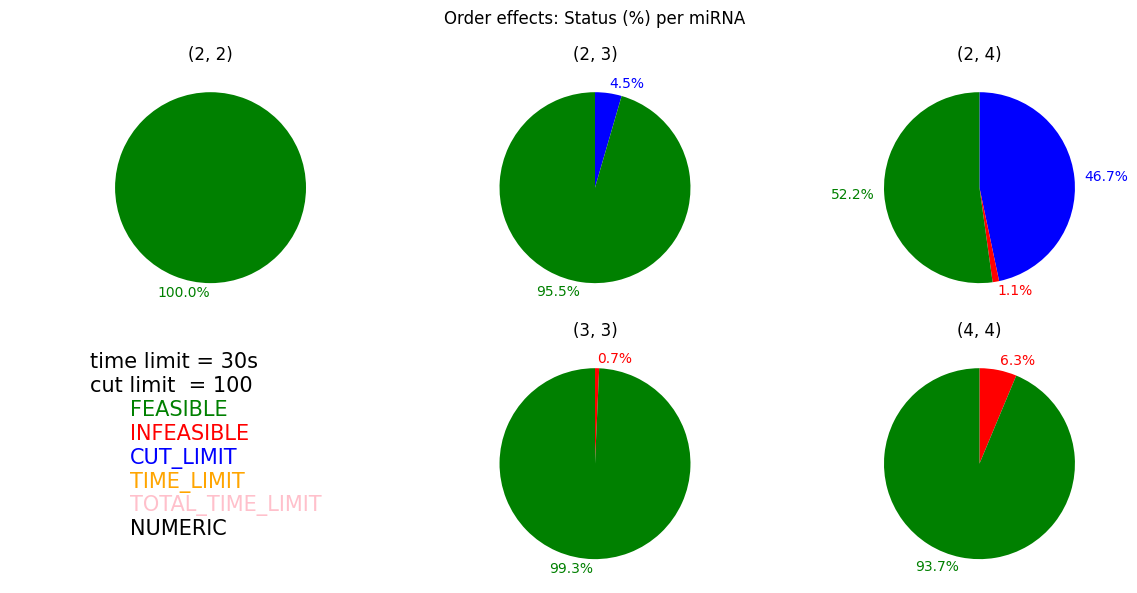

In [160]:
status_pie_chart_order(MF_independent_order_df, 30, 100)

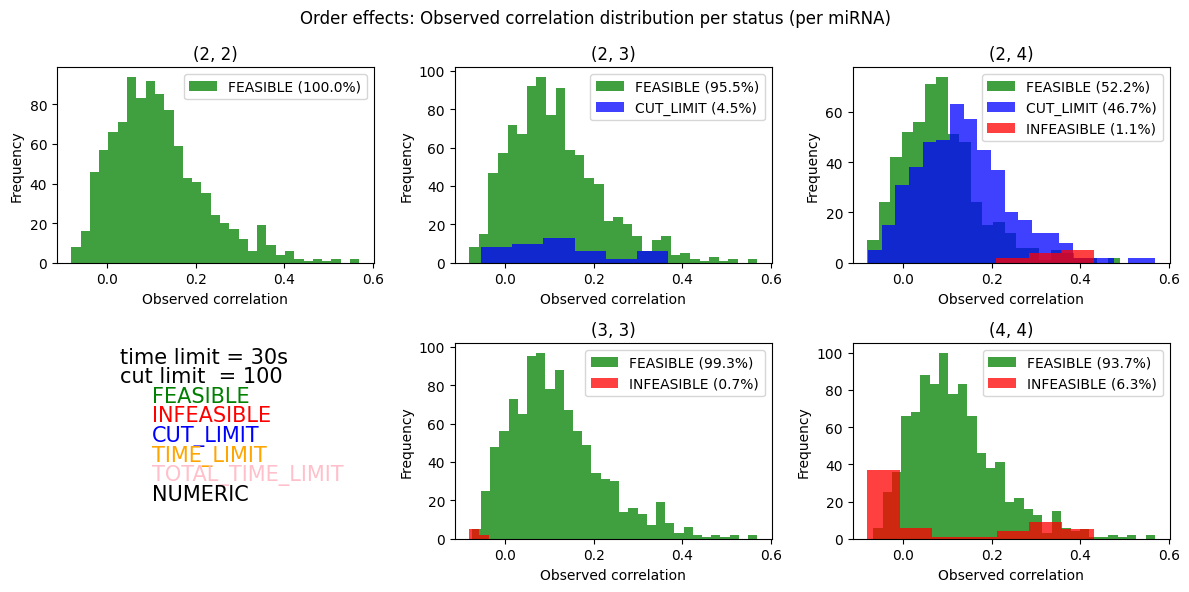

In [161]:
observed_correlation_by_status_histogram_order(MF_independent_order_df, 30, 100)

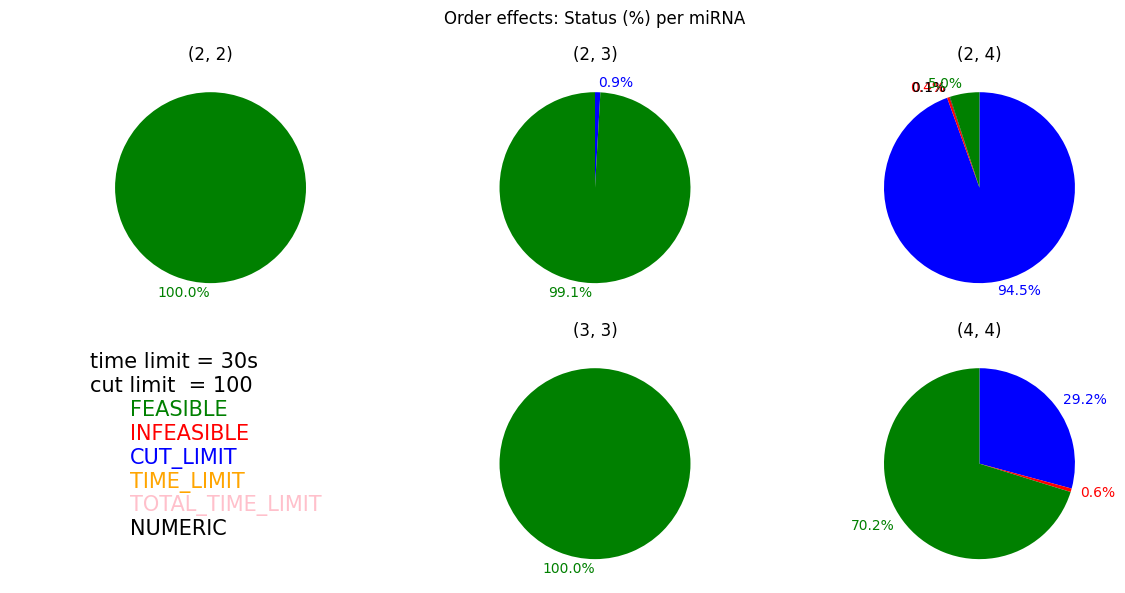

In [162]:
status_pie_chart_order(MF_interacting_order_df, 30, 100)

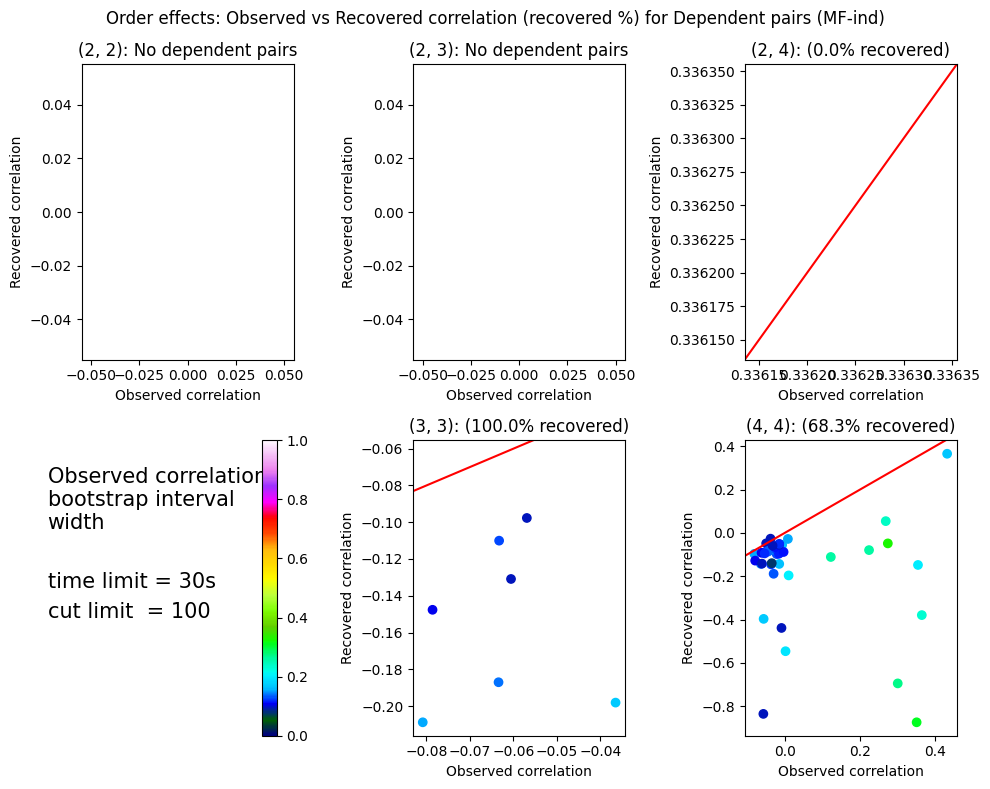

In [163]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 100, dependent=True)

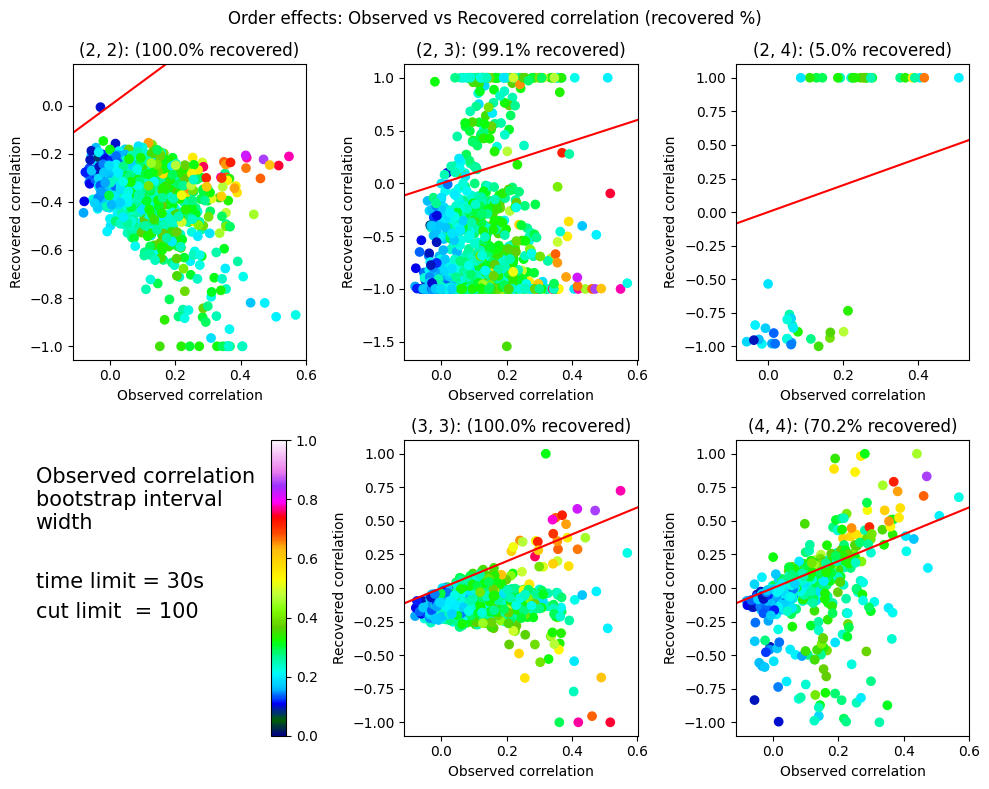

In [164]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 100, dependent=False)

### Cut limit = 1000

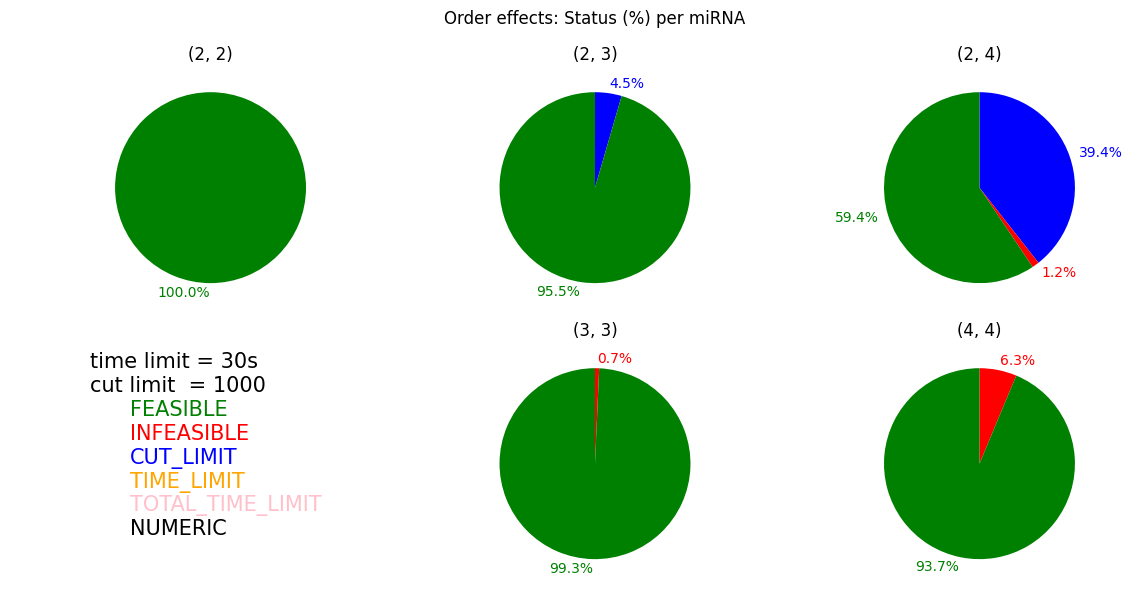

In [165]:
status_pie_chart_order(MF_independent_order_df, 30, 1000)

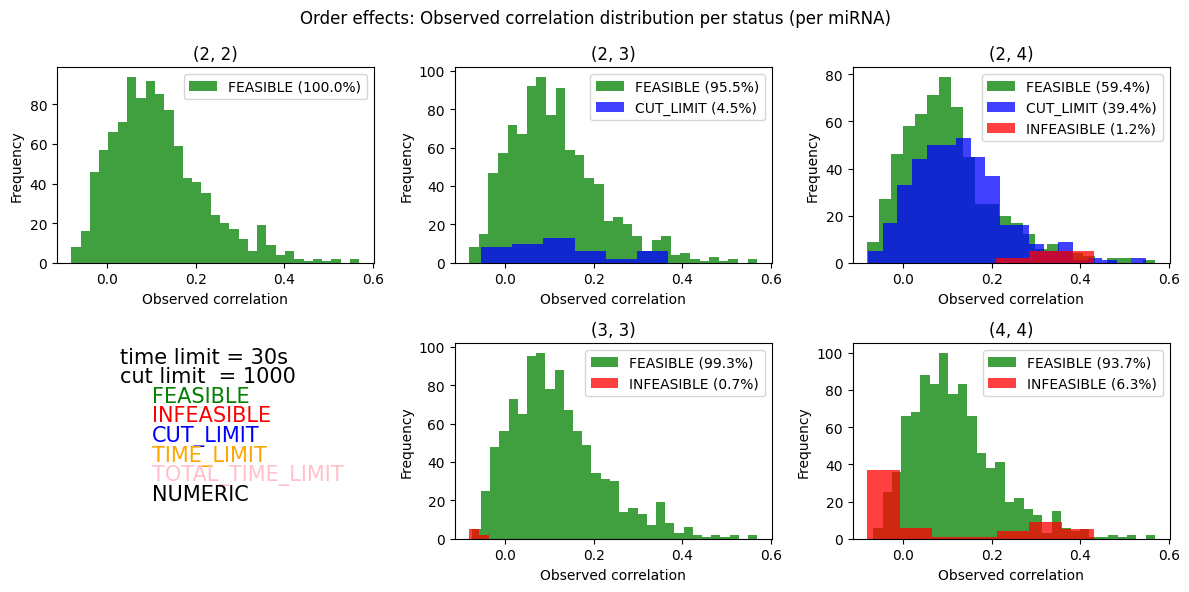

In [166]:
observed_correlation_by_status_histogram_order(MF_independent_order_df, 30, 1000)

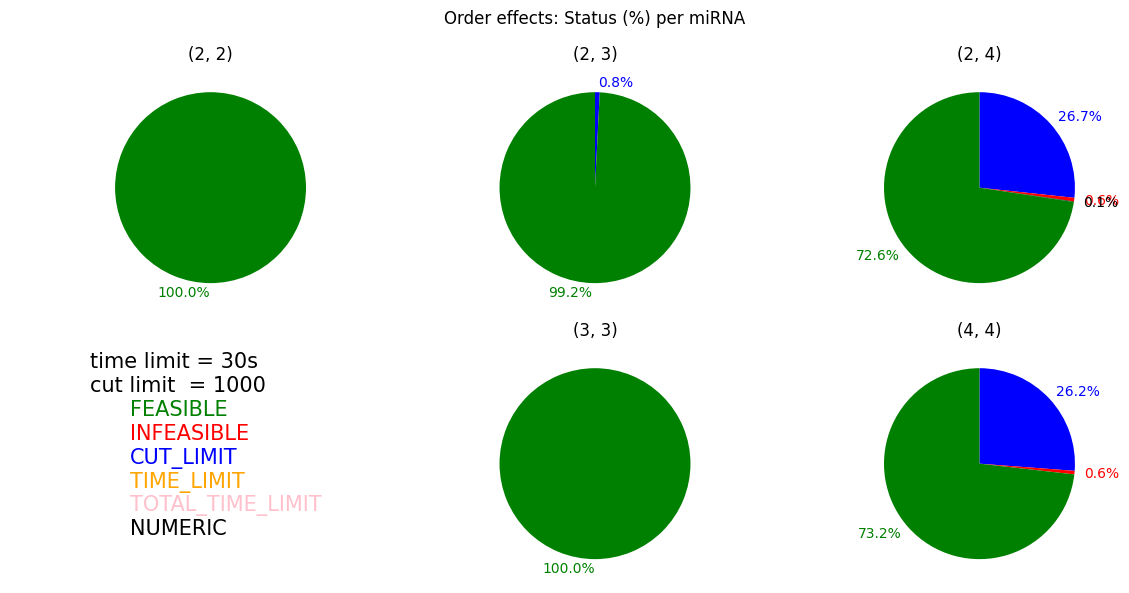

In [167]:
status_pie_chart_order(MF_interacting_order_df, 30, 1000)

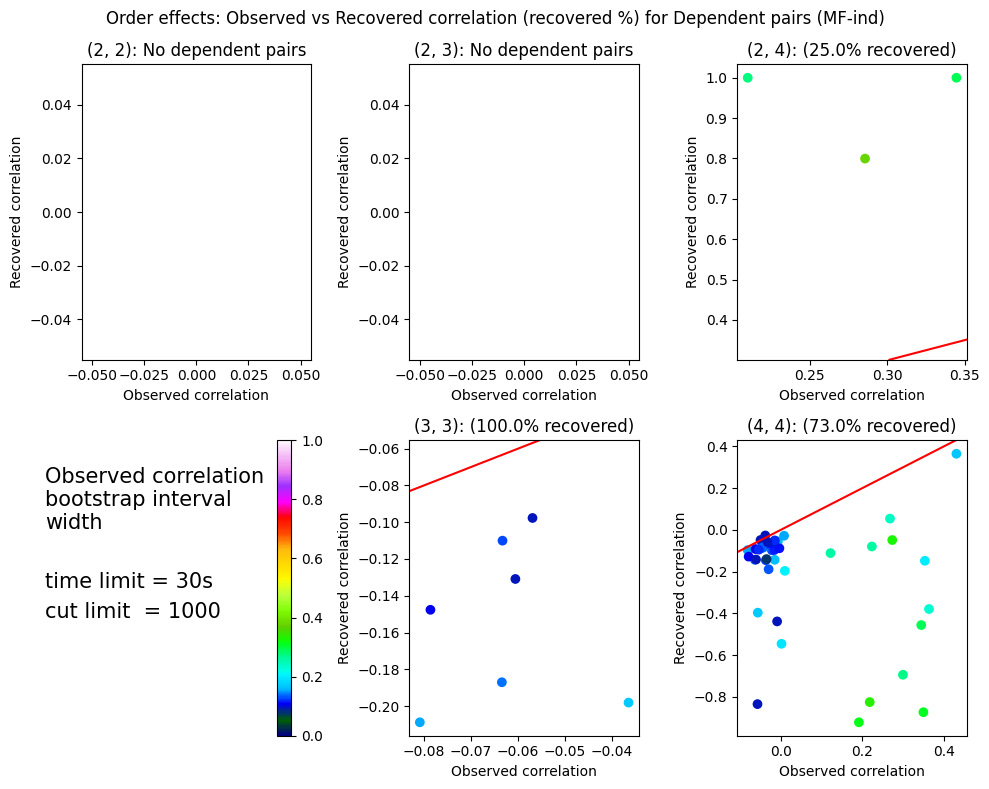

In [168]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 1000, dependent=True)

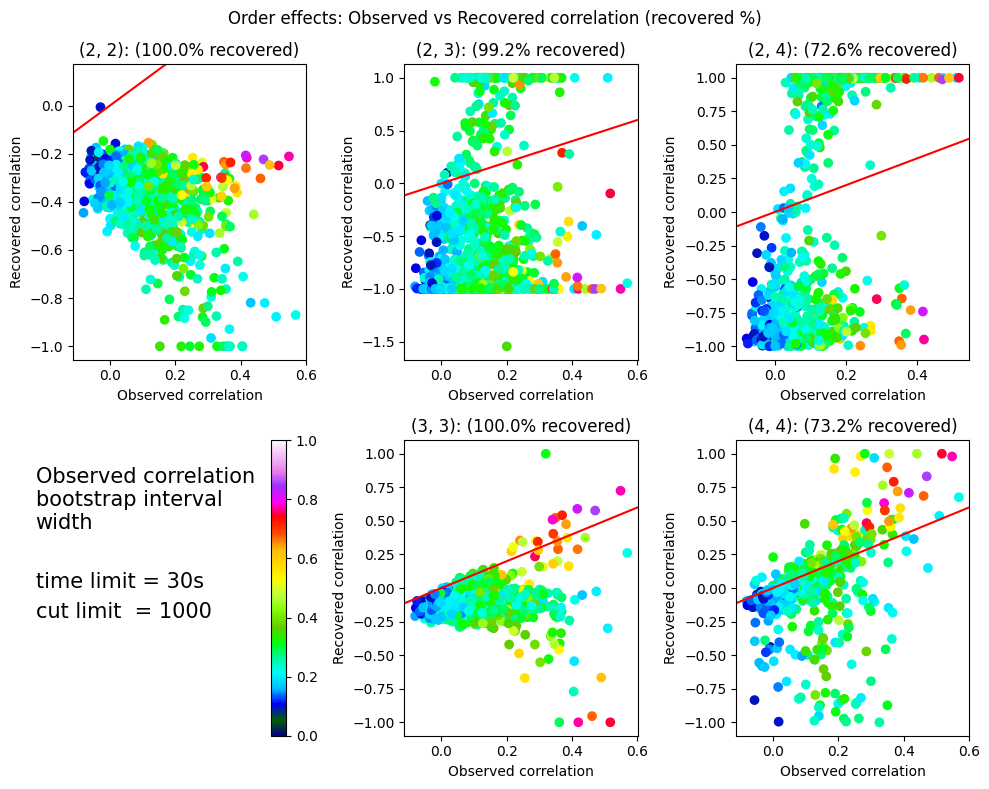

In [169]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 1000, dependent=False)

## MIR199A1

### Cut limit = 100

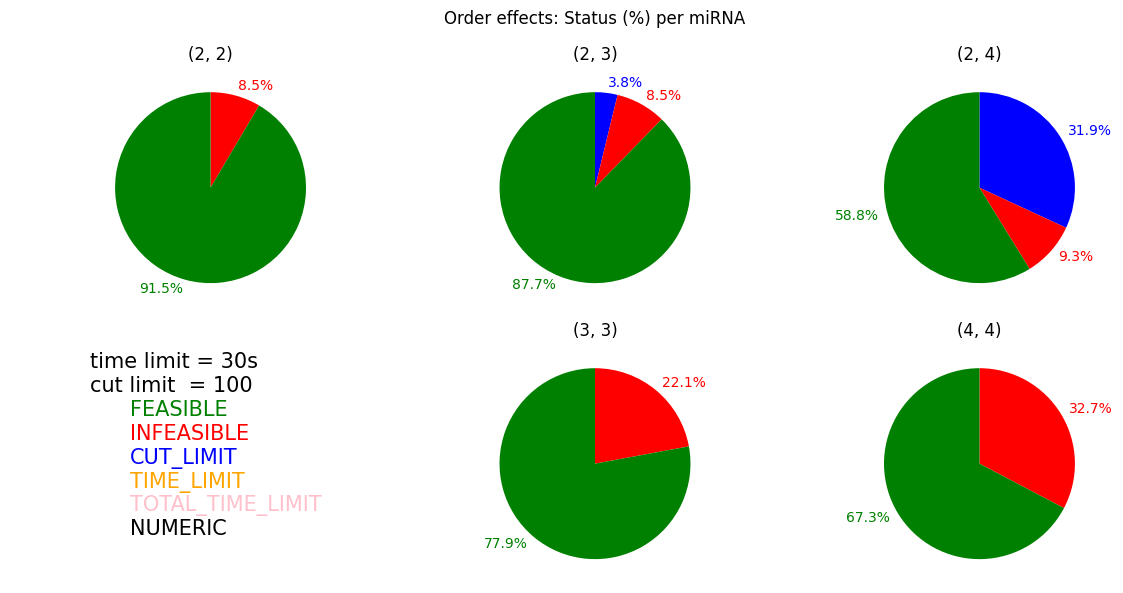

In [155]:
status_pie_chart_order(MF_independent_order_df, 30, 100, miRNA="MIR199A1")

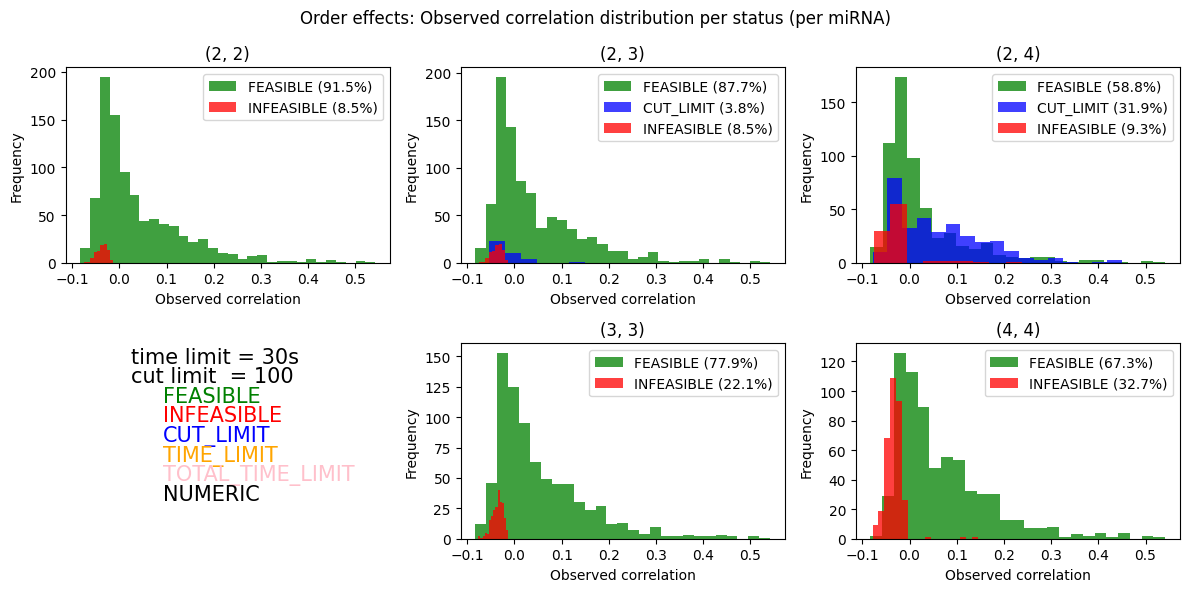

In [156]:
observed_correlation_by_status_histogram_order(MF_independent_order_df, 30, 100, miRNA="MIR199A1")

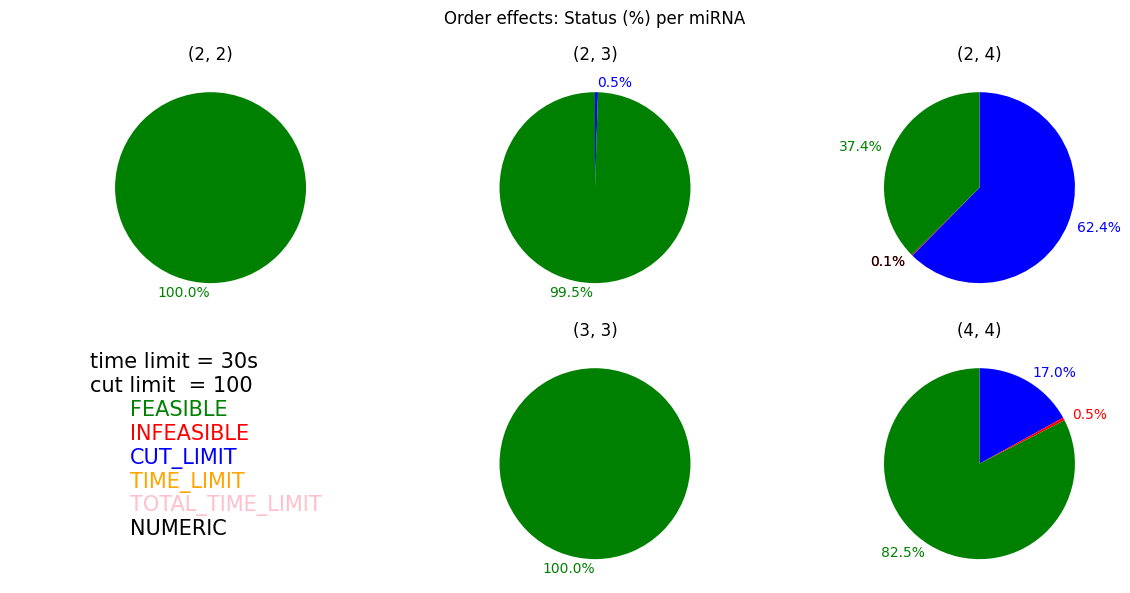

In [157]:
status_pie_chart_order(MF_interacting_order_df, 30, 100, miRNA="MIR199A1")

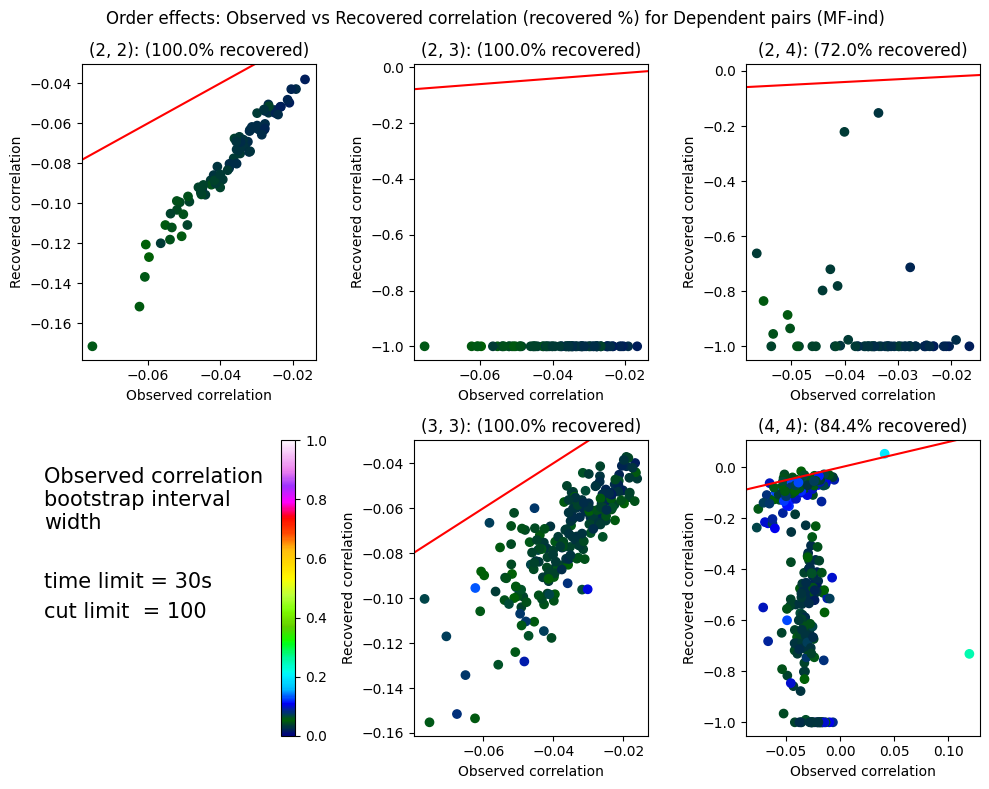

In [158]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 100, dependent=True, miRNA="MIR199A1")

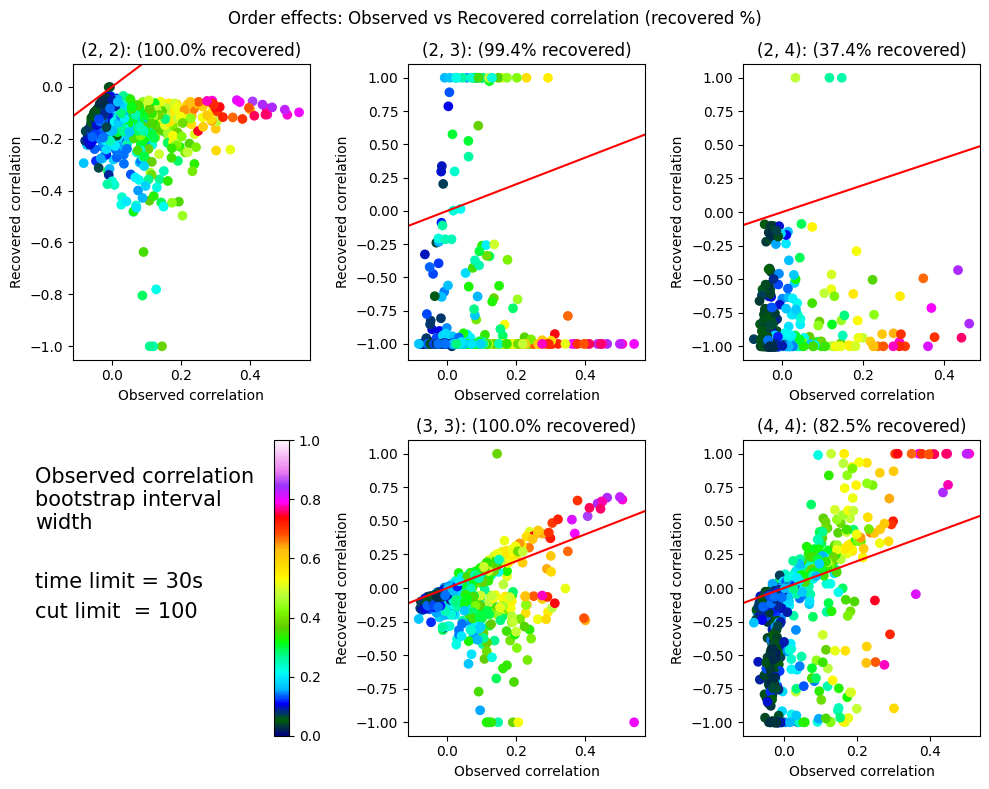

In [159]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 100, dependent=False, miRNA="MIR199A1")

### Cut limit = 1000

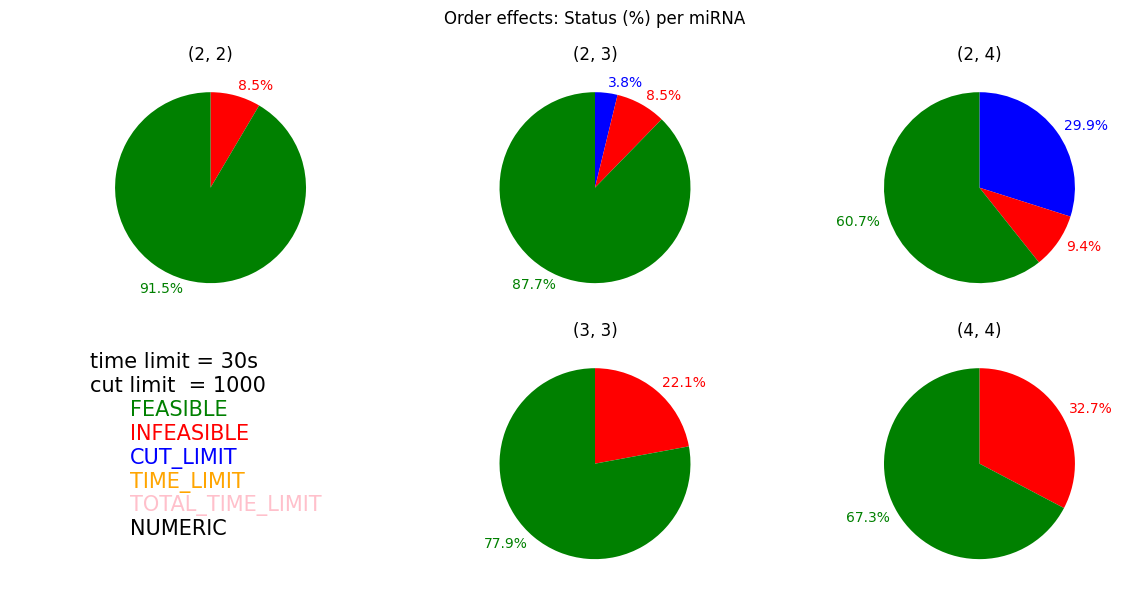

In [175]:
status_pie_chart_order(MF_independent_order_df, 30, 1000, miRNA="MIR199A1")

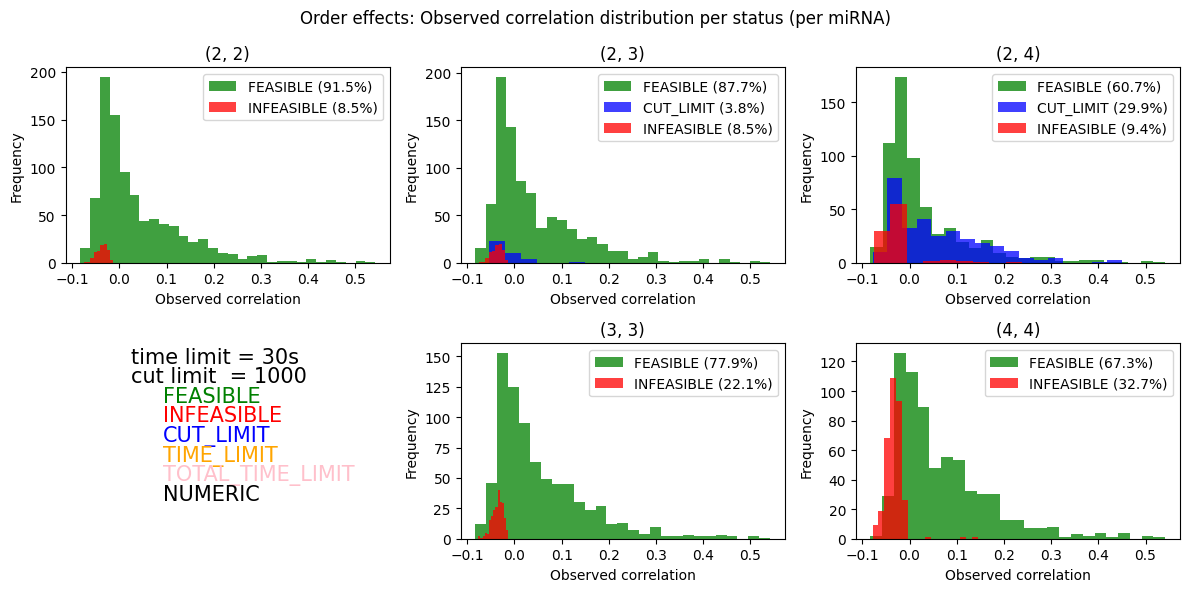

In [176]:
observed_correlation_by_status_histogram_order(MF_independent_order_df, 30, 1000, miRNA="MIR199A1")

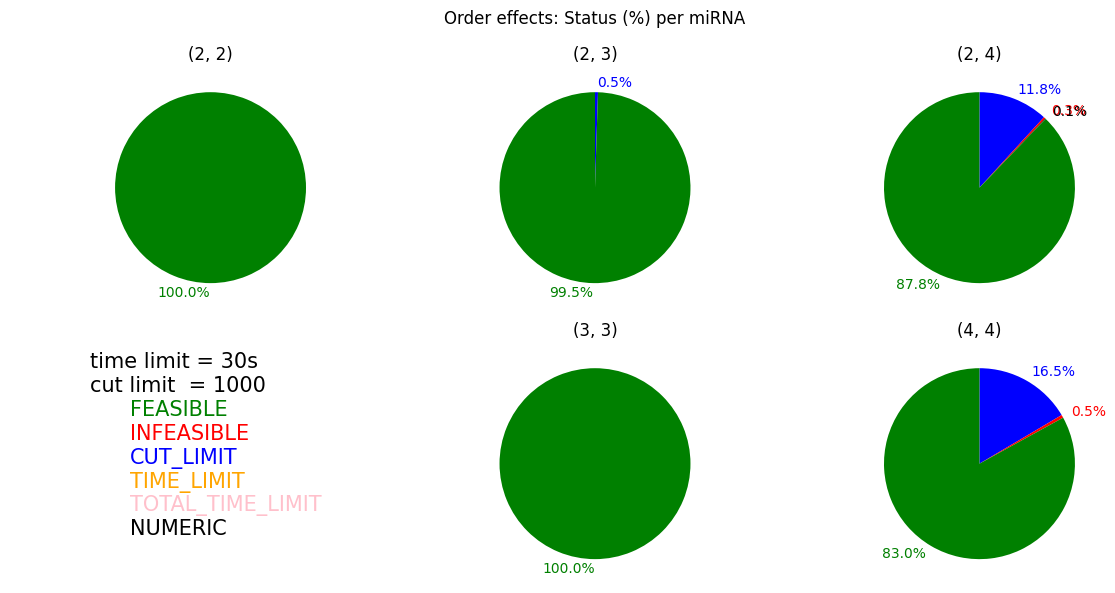

In [177]:
status_pie_chart_order(MF_interacting_order_df, 30, 1000, miRNA="MIR199A1")

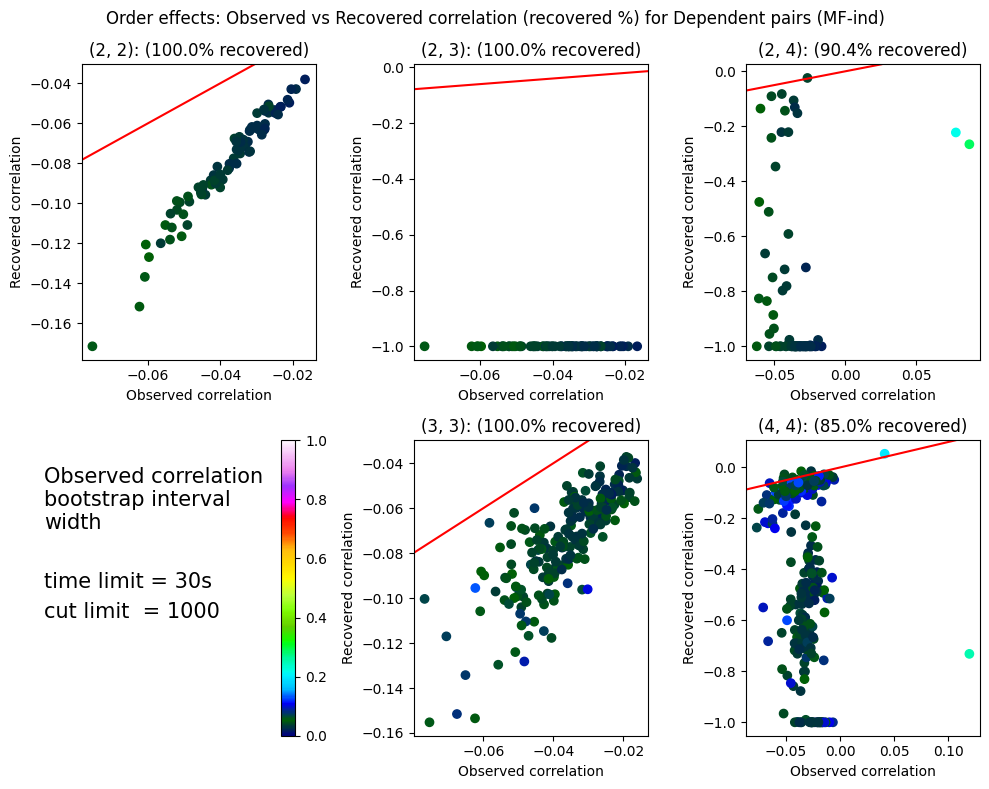

In [178]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 1000, dependent=True, miRNA="MIR199A1")

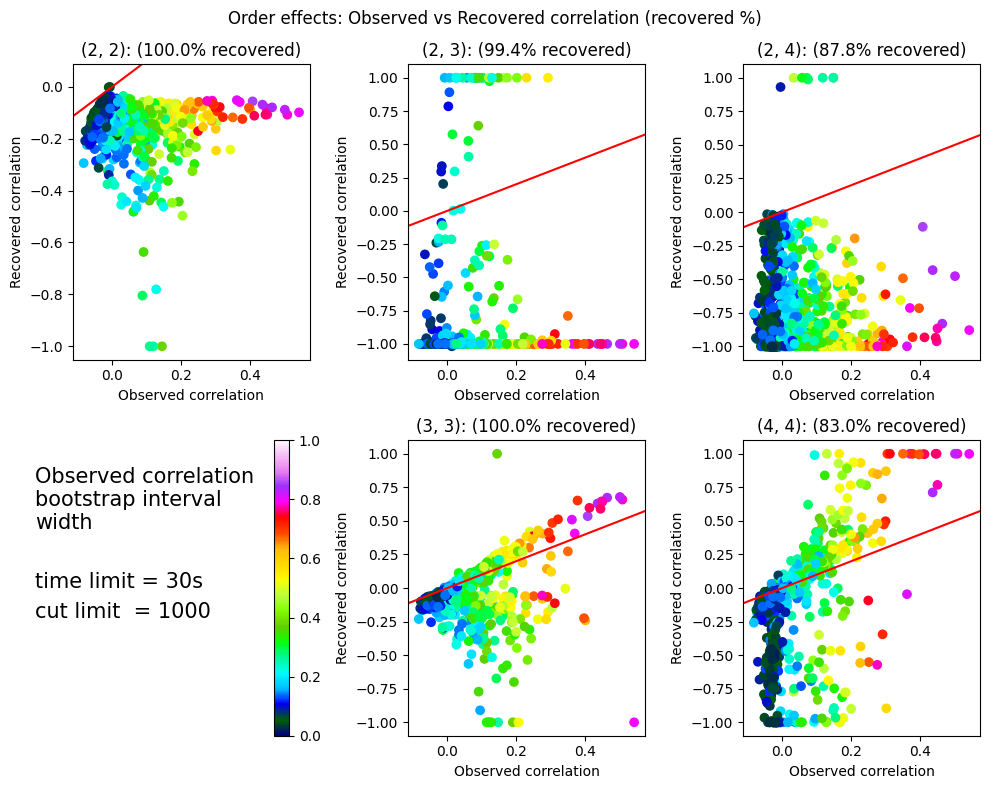

In [179]:
recovered_correlation_scatter_order(MF_interacting_order_df, MF_independent_order_df, 30, 1000, dependent=False, miRNA="MIR199A1")